In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pickle
import importlib
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.decomposition import PCA

import config
from utils.helpers import separate_dataset
from models import SingleTransformer
from train import train_mlm, train_cls
from evaluate import evaluate_mlm, evaluate_cls_cv
from data import load_data, create_dataset
from interpretation.metrics import compute_confusion_matrices, compute_metrics_from_confusion_matrix
from interpretation.visualization import *
from interpretation.similarity import compute_similarity_matrix
from interpretation.latentspace import get_latent_space, analyze_feature_importance

sns.set_style("whitegrid")
sns.set_palette("colorblind")
sns.set_context("paper", font_scale=1.5)

In [2]:
adata_ATAC_labelled, adata_ATAC_unlabelled = load_data.load_atac(data_path="data/datasets/atac/all_atac_d3_motif.h5ad",
                                                                 clone_info=True, clone_path="data/datasets/clone/clones.csv")
# with open('objects/atac_labelled.pkl', 'wb') as f:
#     pickle.dump(adata_ATAC_labelled, f)
# with open('objects/atac_unlabelled.pkl', 'wb') as f:
#     pickle.dump(adata_ATAC_unlabelled, f)


print("ATAC data loaded.",
        "\nATAC D3 Labelled:", adata_ATAC_labelled.shape, adata_ATAC_labelled.obs.shape,  list(adata_ATAC_labelled.var_names)[:5],"...",
        "\nATAC D3 Un-Labelled:", adata_ATAC_unlabelled.shape, adata_ATAC_unlabelled.obs.shape, list(adata_ATAC_unlabelled.var_names)[:5],"...")

ATAC data loaded. 
ATAC D3 Labelled: (265, 883) (265, 12) ['Tcfap2a_1', 'Tcfap2b_2', 'Tcfap2c_3', 'Tcfap2e_4', 'Tcfap2d_5'] ... 
ATAC D3 Un-Labelled: (54824, 883) (54824, 1) ['Tcfap2a_1', 'Tcfap2b_2', 'Tcfap2c_3', 'Tcfap2e_4', 'Tcfap2d_5'] ...


In [3]:
mlm_train_loader, mlm_val_loader = create_dataset.get_mlm_loaders(train_data=adata_ATAC_unlabelled, 
                                                                  val_data=adata_ATAC_labelled, 
                                                                  batch_size=32, 
                                                                  batch_key="batch_no", 
                                                                  data_dtype=torch.float32)

labelled_dataset, pcts, atac_names = create_dataset.get_cls_dataset(data=adata_ATAC_labelled,
                                                    batch_key="batch_no",
                                                    label_key="label",
                                                    pct_key="pct",
                                                    filter_pcts=10.0,
                                                    data_dtype=torch.float32)
print(len(labelled_dataset))

265


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_config = {
    "vocab_size": 1,
    "seq_len": next(iter(mlm_train_loader))[0].shape[-1],
    "d_model": 128,
    # "d_batch": 4,
    "d_ff": 16,
    "n_heads": 8,
    "n_encoder_layers": 2,
    "n_batches": 3,
    "dropout_rate": 0.2
}
model = SingleTransformer(id="ATAC", **model_config).to(device)

  0%|          | 0/1714 [00:00<?, ?it/s]

Epoch 1/10 - Train Loss: 0.0114 - Val Loss: 0.0046, LR: 0.001


  0%|          | 0/1714 [00:00<?, ?it/s]

Epoch 2/10 - Train Loss: 0.0053 - Val Loss: 0.0040, LR: 0.001


  0%|          | 0/1714 [00:00<?, ?it/s]

...

Epoch 8/10 - Train Loss: 0.0028 - Val Loss: 0.0023, LR: 0.001


  0%|          | 0/1714 [00:00<?, ?it/s]

Epoch 9/10 - Train Loss: 0.0026 - Val Loss: 0.0022, LR: 0.001


  0%|          | 0/1714 [00:00<?, ?it/s]

Epoch 10/10 - Train Loss: 0.0025 - Val Loss: 0.0019, LR: 0.001
Model saved at ckp/MLM/MLM_ATAC_ValLoss0.0019.pth
Training completed.


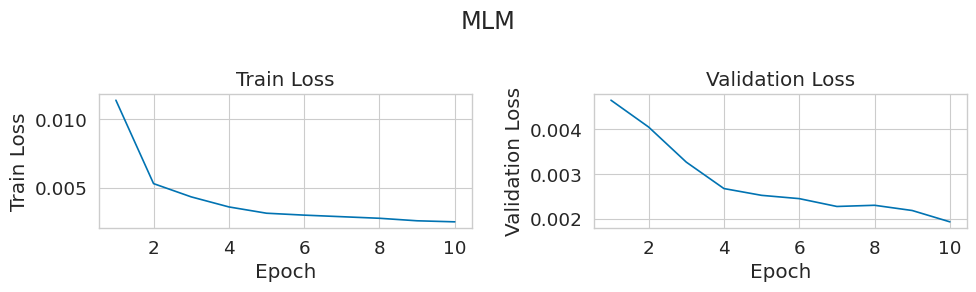

In [5]:
mlm_train_loss, mlm_val_loss = train_mlm(model, mlm_train_loader, mlm_val_loader, device,
                                            mse_based=True, epochs=10, lr=1e-3, weight_decay=0, tune_lr=True, 
                                            save_folder="ckp/MLM/", id="ATAC", use_multiple_gpu=False)
plot_training_vs_validation_losses(mlm_train_loss, mlm_val_loss, "MLM")

In [6]:
importlib.reload(config)
model.load_state_dict(torch.load(config.MLM_ATAC_CKP))
print(f"Model loaded from checkpoint: {config.MLM_ATAC_CKP}")
val_loss = evaluate_mlm(model, mlm_val_loader, mask_token=-1, mse_based=True, device=device)
print(f"Validation Loss: {val_loss:.4f}")

Model loaded from checkpoint: ckp/MLM/MLM_ATAC_ValLoss0.0019.pth


Evaluating MLM:   0%|          | 0/9 [00:00<?, ?it/s]

Validation Loss: 0.0020


In [9]:
importlib.reload(config)
fold_results = train_cls("ATAC", model_config, 
                        labelled_dataset, k_folds=5, batch_size=32, 
                        epochs=15, lr=1e-3, weight_decay=1e-4,
                        use_mlm=True, mlm_path="ckp/MLM/MLM_ATAC_ValLoss0.0019.pth", save_path="ckp/CLS", 
                        device=device, loss_fn="w_bce", seed=0)

print(f"Cross-Validation Results:\n"
    f"Train AUC: {np.mean([fr['train_auc'] for fr in fold_results]):.4f} ± {np.std([fr['train_auc'] for fr in fold_results]):.4f}, "
    f"Valid AUC: {np.mean([fr['best_val_auc'] for fr in fold_results]):.4f} ± {np.std([fr['best_val_auc'] for fr in fold_results]):.4f}, "
    f"Precision: {np.mean([fr['best_precision'] for fr in fold_results]):.4f} ± {np.std([fr['best_precision'] for fr in fold_results]):.4f}, "
    f"Recall: {np.mean([fr['best_recall'] for fr in fold_results]):.4f} ± {np.std([fr['best_recall'] for fr in fold_results]):.4f}, "
    f"F1: {np.mean([fr['best_f1'] for fr in fold_results]):.4f} ± {np.std([fr['best_f1'] for fr in fold_results]):.4f}, "
    f"Accuracy: {np.mean([fr['best_accuracy'] for fr in fold_results]):.4f} ± {np.std([fr['best_accuracy'] for fr in fold_results]):.4f}")

Fold 1/5
Positive weight: 0.404
Epoch 1/15, Loss: (0.5561 | 0.6548), Model AUC: (0.8578 | 0.8480), Precision: 0.6981, Recall: 1.0000, F1: 0.8222, Acc: 0.6981 | lr: 0.001
Epoch 2/15, Loss: (0.5221 | 0.5857), Model AUC: (0.8646 | 0.8699), Precision: 0.6981, Recall: 1.0000, F1: 0.8222, Acc: 0.6981 | lr: 0.001
Epoch 3/15, Loss: (0.4713 | 0.5060), Model AUC: (0.8597 | 0.8716), Precision: 0.9211, Recall: 0.9459, F1: 0.9333, Acc: 0.9057 | lr: 0.001
Epoch 4/15, Loss: (0.3589 | 0.3411), Model AUC: (0.8744 | 0.8699), Precision: 0.9189, Recall: 0.9189, F1: 0.9189, Acc: 0.8868 | lr: 0.001
Epoch 5/15, Loss: (0.2998 | 0.3898), Model AUC: (0.9124 | 0.8834), Precision: 0.8974, Recall: 0.9459, F1: 0.9211, Acc: 0.8868 | lr: 0.001
Epoch 6/15, Loss: (0.2909 | 0.4179), Model AUC: (0.9063 | 0.8733), Precision: 0.8750, Recall: 0.9459, F1: 0.9091, Acc: 0.8679 | lr: 0.001
Epoch 7/15, Loss: (0.2816 | 0.4405), Model AUC: (0.9163 | 0.8716), Precision: 0.8750, Recall: 0.9459, F1: 0.9091, Acc: 0.8679 | lr: 0.001
Ep

In [ ]:
fold_results_nomlm = train_cls("ATAC", model_config, 
                            labelled_dataset, k_folds=5, batch_size=32, 
                            epochs=15, lr=1e-3, weight_decay=1e-4,
                            use_mlm=False, mlm_path=None, save_path="ckp/CLS", 
                            device=device, loss_fn="w_bce", seed=0)

print(f"Cross-Validation Results:\n"
    f"Train AUC: {np.mean([fr['train_auc'] for fr in fold_results_nomlm]):.4f} ± {np.std([fr['train_auc'] for fr in fold_results_nomlm]):.4f}, "
    f"Valid AUC: {np.mean([fr['best_val_auc'] for fr in fold_results_nomlm]):.4f} ± {np.std([fr['best_val_auc'] for fr in fold_results_nomlm]):.4f}, "
    f"Precision: {np.mean([fr['best_precision'] for fr in fold_results_nomlm]):.4f} ± {np.std([fr['best_precision'] for fr in fold_results_nomlm]):.4f}, "
    f"Recall: {np.mean([fr['best_recall'] for fr in fold_results_nomlm]):.4f} ± {np.std([fr['best_recall'] for fr in fold_results_nomlm]):.4f}, "
    f"F1: {np.mean([fr['best_f1'] for fr in fold_results_nomlm]):.4f} ± {np.std([fr['best_f1'] for fr in fold_results_nomlm]):.4f}, "
    f"Accuracy: {np.mean([fr['best_accuracy'] for fr in fold_results_nomlm]):.4f} ± {np.std([fr['best_accuracy'] for fr in fold_results_nomlm]):.4f}")

Fold 1/5
Positive weight: 0.404
Epoch 1/15, Loss: (0.6164 | 0.7026), Model AUC: (0.6266 | 0.6275), Precision: 0.0000, Recall: 0.0000, F1: 0.0000, Acc: 0.3019 | lr: 0.001
Epoch 2/15, Loss: (0.5532 | 0.6224), Model AUC: (0.6157 | 0.6605), Precision: 0.6981, Recall: 1.0000, F1: 0.8222, Acc: 0.6981 | lr: 0.001
Epoch 3/15, Loss: (0.5353 | 0.6445), Model AUC: (0.6207 | 0.6402), Precision: 0.6981, Recall: 1.0000, F1: 0.8222, Acc: 0.6981 | lr: 0.001
Epoch 4/15, Loss: (0.5284 | 0.6177), Model AUC: (0.5918 | 0.5878), Precision: 0.6981, Recall: 1.0000, F1: 0.8222, Acc: 0.6981 | lr: 0.001
Epoch 5/15, Loss: (0.5225 | 0.6215), Model AUC: (0.6042 | 0.6132), Precision: 0.6981, Recall: 1.0000, F1: 0.8222, Acc: 0.6981 | lr: 0.001
Epoch 6/15, Loss: (0.5143 | 0.6200), Model AUC: (0.6237 | 0.6436), Precision: 0.6981, Recall: 1.0000, F1: 0.8222, Acc: 0.6981 | lr: 0.0005
Epoch 7/15, Loss: (0.5183 | 0.6175), Model AUC: (0.6257 | 0.6419), Precision: 0.6981, Recall: 1.0000, F1: 0.8222, Acc: 0.6981 | lr: 0.0005


In [5]:
# with open('objects/atac_fold_results_mlm_last_l_conc1.pkl', 'wb') as f:
#     pickle.dump(fold_results, f)
# with open('objects/atac_fold_results_nomlm_last_l_conc.pkl', 'wb') as f:
#     pickle.dump(fold_results_nomlm, f)

with open('objects/atac_fold_results_mlm_last_l_conc1.pkl', 'rb') as f:
    fold_results = pickle.load(f)
with open('objects/atac_fold_results_nomlm_last_l_conc.pkl', 'rb') as f:
        fold_results_nomlm = pickle.load(f)

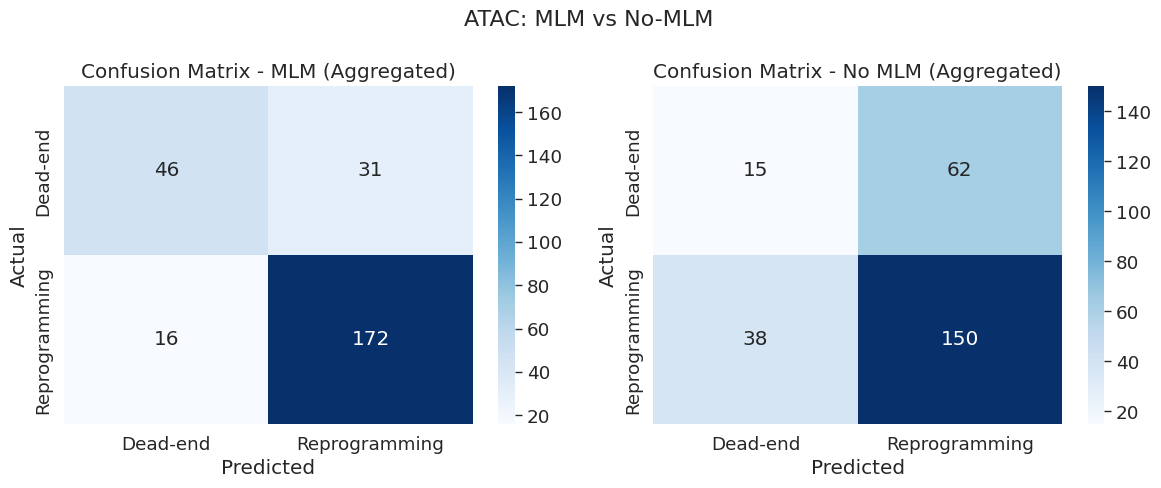

In [6]:
cms_mlm = compute_confusion_matrices("ATAC", model_config, fold_results, labelled_dataset, device)
cms_nomlm = compute_confusion_matrices("ATAC", model_config, fold_results_nomlm, labelled_dataset, device)
plot_conf_matrix_mlm_vs_nomlm(cms_mlm, cms_nomlm, m_type="ATAC", only_agg=True, suptitle="ATAC: MLM vs No-MLM")

In [7]:
# compute mean and std of train_auc and best_val_auc keys in fold_results and fold_results_nomlm
train_auc_mlm = np.mean([fr['train_auc'] for fr in fold_results])
train_auc_nomlm = np.mean([fr['train_auc'] for fr in fold_results_nomlm])
train_auc_mlm_std = np.std([fr['train_auc'] for fr in fold_results])
train_auc_nomlm_std = np.std([fr['train_auc'] for fr in fold_results_nomlm])
best_val_auc_mlm = np.mean([fr['best_val_auc'] for fr in fold_results])
best_val_auc_nomlm = np.mean([fr['best_val_auc'] for fr in fold_results_nomlm])
best_val_auc_mlm_std = np.std([fr['best_val_auc'] for fr in fold_results])
best_val_auc_nomlm_std = np.std([fr['best_val_auc'] for fr in fold_results_nomlm])

print(f"Train AUC: MLM: {train_auc_mlm:.4f} ± {train_auc_mlm_std:.4f}, No-MLM: {train_auc_nomlm:.4f} ± {train_auc_nomlm_std:.4f}")
print(f"Best Val AUC: MLM: {best_val_auc_mlm:.4f} ± {best_val_auc_mlm_std:.4f}, No-MLM: {best_val_auc_nomlm:.4f} ± {best_val_auc_nomlm_std:.4f}")

Train AUC: MLM: 0.8931 ± 0.0403, No-MLM: 0.6283 ± 0.0157
Best Val AUC: MLM: 0.8852 ± 0.0540, No-MLM: 0.6393 ± 0.0753


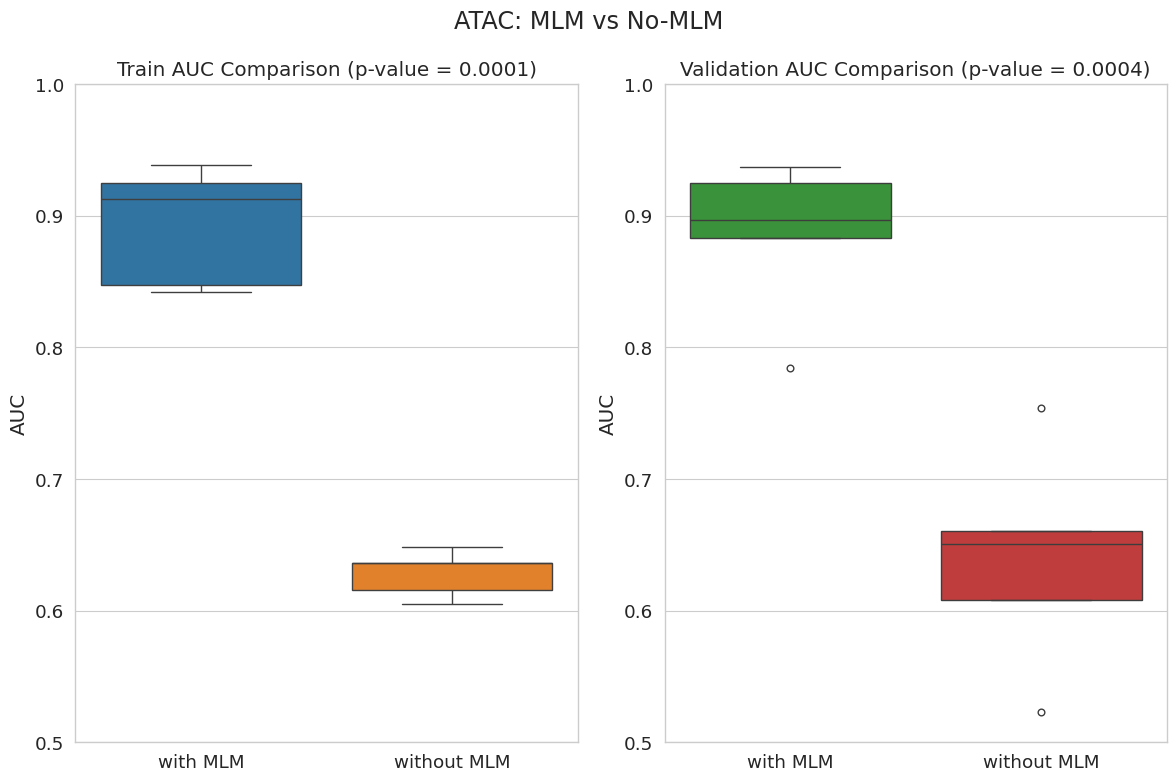

In [8]:
plot_auc_boxplot_comparison(fold_results, fold_results_nomlm, title="ATAC: MLM vs No-MLM")

In [9]:
metrics_mlm = compute_metrics_from_confusion_matrix(cms_mlm)
metrics_nomlm = compute_metrics_from_confusion_matrix(cms_nomlm)

avg_mlm = metrics_mlm["average"]
std_mlm = metrics_mlm["std"]
avg_nomlm = metrics_nomlm["average"]
std_nomlm = metrics_nomlm["std"]

print("ATAC: MLM")
for k, v in avg_mlm.items():
    print(f"{k}: {v:.4f} ± {std_mlm[k]:.4f}")
print("\nATAC: No-MLM")
for k, v in avg_nomlm.items():
    print(f"{k}: {v:.4f} ± {std_nomlm[k]:.4f}")

ATAC: MLM
precision: 0.8646 ± 0.0868
recall: 0.9155 ± 0.1303
f1: 0.8780 ± 0.0634
accuracy: 0.8226 ± 0.0865

ATAC: No-MLM
precision: 0.5660 ± 0.2831
recall: 0.8000 ± 0.4000
f1: 0.6630 ± 0.3315
accuracy: 0.6226 ± 0.1700


In [10]:
# print each fold best val auc separate based on mlm and no mlm 5 folds for each)
for i in range(5):
    print(f"Fold {i+1}: MLM: {fold_results[i]['best_val_auc']:.4f}, No-MLM: {fold_results_nomlm[i]['best_val_auc']:.4f}")
print(f"val auc mlm: {np.mean([fr['best_val_auc'] for fr in fold_results]):.4f} ± {np.std([fr['best_val_auc'] for fr in fold_results]):.4f}")
print(f"val auc no mlm: {np.mean([fr['best_val_auc'] for fr in fold_results_nomlm]):.4f} ± {np.std([fr['best_val_auc'] for fr in fold_results_nomlm]):.4f}")
# compute p-value for mlm and no-mlm values for val auc
from scipy.stats import ttest_rel
print("p-value for val auc: ", ttest_rel([fr['best_val_auc'] for fr in fold_results], [fr['best_val_auc'] for fr in fold_results_nomlm]))

Fold 1: MLM: 0.8834, No-MLM: 0.6605
Fold 2: MLM: 0.8970, No-MLM: 0.6081
Fold 3: MLM: 0.9368, No-MLM: 0.6509
Fold 4: MLM: 0.9246, No-MLM: 0.7544
Fold 5: MLM: 0.7842, No-MLM: 0.5228
val auc mlm: 0.8852 ± 0.0540
val auc no mlm: 0.6393 ± 0.0753
p-value for val auc:  TtestResult(statistic=11.023269570027491, pvalue=0.000384990770818786, df=4)


Evaluating Classifier: 0it [00:00, ?it/s]

['(0.8834 | 0.8834)', '(0.8970 | 0.8970)', '(0.9368 | 0.9368)', '(0.9246 | 0.9246)', '(0.7842 | 0.7842)']


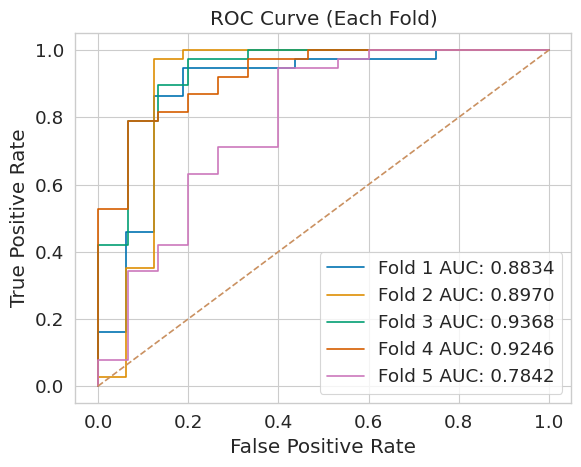

In [11]:
aucs_stored, aucs, val_preds, val_labels = evaluate_cls_cv("ATAC", fold_results, model_config, labelled_dataset, device)
print([f"({a:.4f} | {b:.4f})" for a,b in zip(aucs_stored, aucs)])
plot_roc_auc_curve(val_preds, val_labels, m_type="ATAC", aggregate=False)

In [12]:
import json
data_to_store = {
    "modality": "ATAC",
    "val_preds": [val_preds[i].tolist() for i in range(5)],
    "val_labels": [val_labels[i].tolist() for i in range(5)]
}
with open('objects/ATAC_val_preds.json', 'w') as f:
    json.dump(data_to_store, fp=f)

## Plot Similarity Heatmap

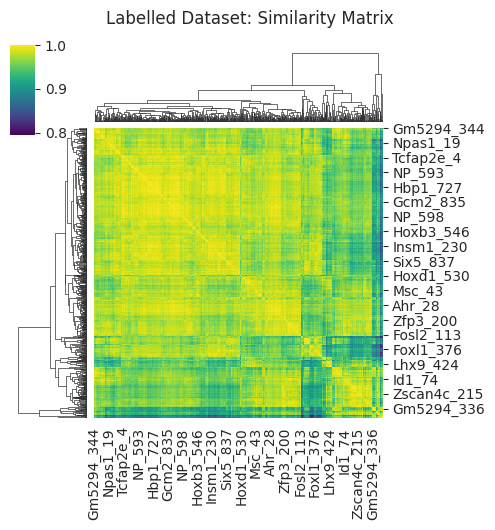

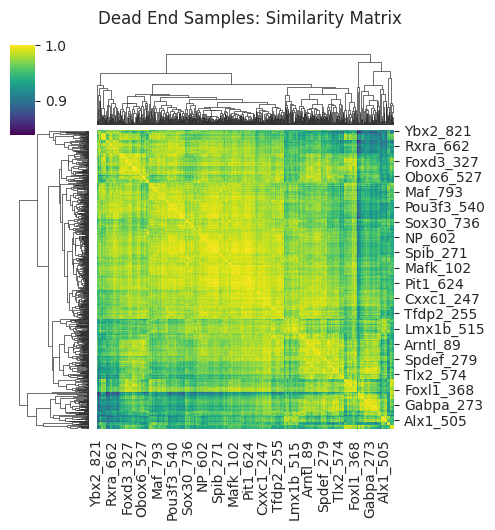

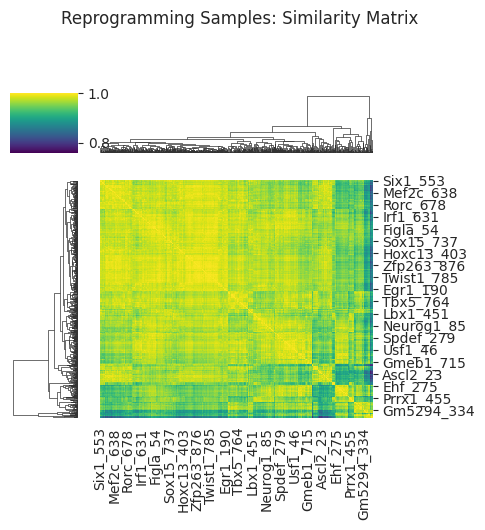

In [14]:
# Compute Similarity Matrix
dead_end_ds, repro_ds = separate_dataset(labelled_dataset)

model = SingleTransformer(id="ATAC", **model_config).to(device)
model.load_state_dict(torch.load(config.MLM_ATAC_CKP))

sm_labelled = compute_similarity_matrix(model, labelled_dataset, device)
sm_dead_end = compute_similarity_matrix(model, dead_end_ds, device)
sm_repro = compute_similarity_matrix(model, repro_ds, device)

# Create clustermap for Labelled Dataset
df_labelled = pd.DataFrame(sm_labelled, index=atac_names, columns=atac_names)
g1 = sns.clustermap(df_labelled, row_cluster=True, col_cluster=True, cmap="viridis", figsize=(5, 5))
g1.fig.suptitle("Labelled Dataset: Similarity Matrix", y=1.05)

# Create clustermap for Dead End Dataset
df_dead_end = pd.DataFrame(sm_dead_end, index=atac_names, columns=atac_names)
g2 = sns.clustermap(df_dead_end, row_cluster=True, col_cluster=True, cmap="viridis", figsize=(5, 5))
g2.fig.suptitle("Dead End Samples: Similarity Matrix", y=1.05)

# Create clustermap for Reproducible Dataset
df_repro = pd.DataFrame(sm_repro, index=atac_names, columns=atac_names)
g3 = sns.clustermap(df_repro, row_cluster=True, col_cluster=True, cmap="viridis", figsize=(5, 5))
g3.fig.suptitle("Reprogramming Samples: Similarity Matrix", y=1.05)

plt.tight_layout()
plt.show()

## Analyse Wrong Predictions

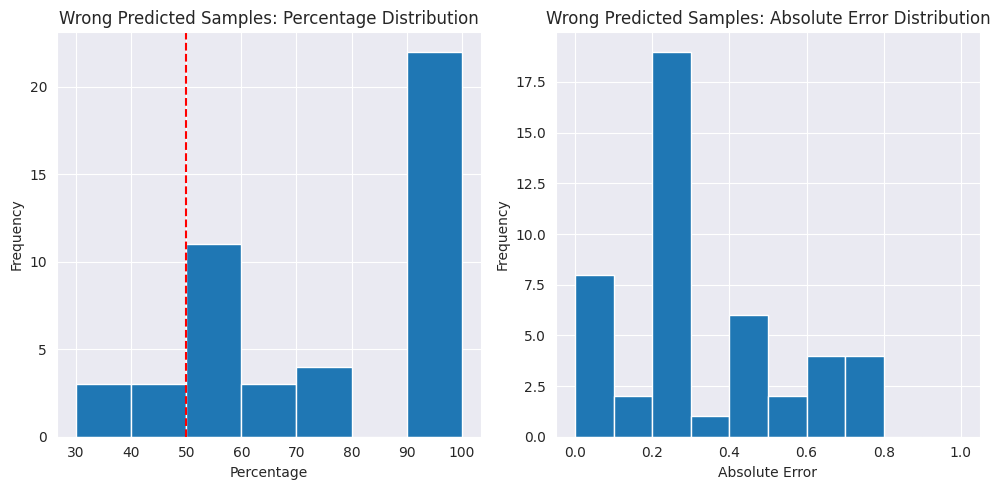

In [15]:
# get valid indices from val_index of fold_results
val_indices = [fr['val_idx'] for fr in fold_results]
# get wrong predicted samples from val_preds and val_labels and val_indices
wrong_preds = []
wrong_indices = []
for p, g, i in zip(np.concatenate(val_preds), np.concatenate(val_labels), np.concatenate(val_indices)):
    if p.round() != g:
        wrong_preds.append(p)
        wrong_indices.append(i)
wrong_pcts = pcts[wrong_indices].numpy().tolist()

# plot wrong_pcts with 10 period bins histogram and plot abs(1- wrong_preds) histogram with 0.1 period bins 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.hist(wrong_pcts, bins=7, range=(30, 100))
ax1.axvline(x=50, color='red', linestyle='--')
ax1.set_title("Wrong Predicted Samples: Percentage Distribution")
ax1.set_xlabel("Percentage")
ax1.set_ylabel("Frequency")

ax2.hist(np.abs(1 - np.array(wrong_preds)), bins=10, range=(0, 1))
ax2.set_title("Wrong Predicted Samples: Absolute Error Distribution")
ax2.set_xlabel("Absolute Error")
ax2.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# # get indices of top 30 wrong predicted samples with highest absolute error
# top_30_wrong_indices = np.argsort(np.abs(1 - np.array(wrong_preds)))[-30:]
# top_30_wrong_pcts = pcts[wrong_indices][top_30_wrong_indices].numpy().tolist()

# # plot top_30_wrong_pcts with 10 period bins histogram and plot abs(1- wrong_preds) histogram with 0.1 period bins
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# ax1.hist(top_30_wrong_pcts, bins=7, range=(30, 100))
# ax1.axvline(x=50, color='red', linestyle='--')
# ax1.set_title("Top 30 Wrong Predicted Samples: Percentage Distribution")
# ax1.set_xlabel("Percentage")
# ax1.set_ylabel("Frequency")

# ax2.hist(np.abs(1 - np.array(wrong_preds))[top_30_wrong_indices], bins=10, range=(0, 1))
# ax2.set_title("Top 30 Wrong Predicted Samples: Absolute Error Distribution")
# ax2.set_xlabel("Absolute Error")
# ax2.set_ylabel("Frequency")

# plt.tight_layout()
# plt.show()

## Plot Latent Space (CLS Token Embeddings)

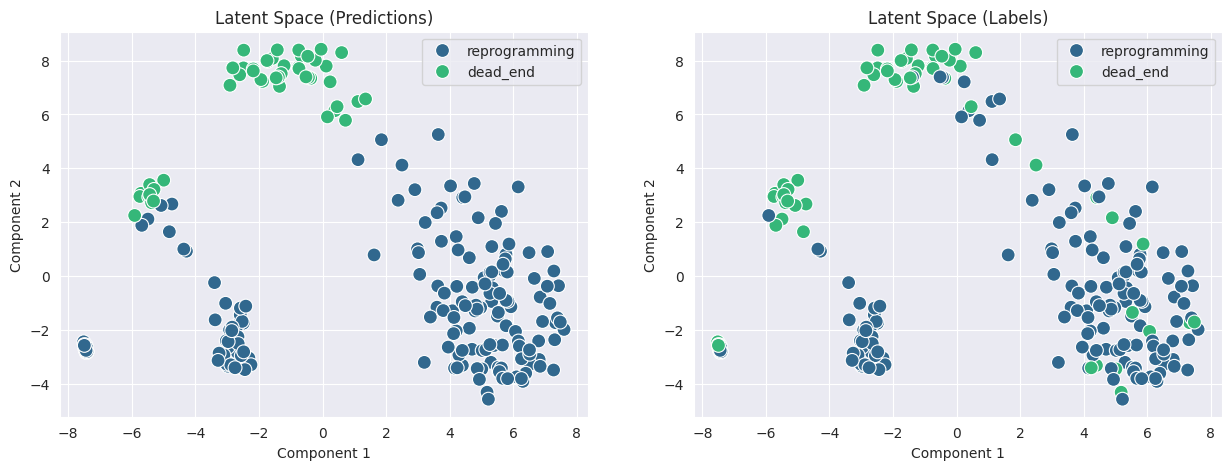

In [16]:
ls, labels, preds = get_latent_space("ATAC", fold_results, labelled_dataset, model_config, device)

pca = PCA(n_components=2)
reduced_latent_space = pca.fit_transform(ls)

labels_str = ['reprogramming' if l == 1 else 'dead_end' for l in labels]
preds_str = ['reprogramming' if l == 1 else 'dead_end' for l in preds]
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=reduced_latent_space[:, 0], y=reduced_latent_space[:, 1], hue=preds_str, palette="viridis", s=100)
plt.title('Latent Space (Predictions)')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.subplot(1, 2, 2)
sns.scatterplot(x=reduced_latent_space[:, 0], y=reduced_latent_space[:, 1], hue=labels_str, palette="viridis", s=100)
plt.title('Latent Space (Labels)')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.show()

## Analyse Shift in Latent Space

In [17]:
feature_importance = analyze_feature_importance("ATAC", model_config, fold_results, labelled_dataset, atac_names, device, perturbation_scale=0.1)

100%|██████████| 883/883 [02:40<00:00,  5.50it/s]


Foxl1_364: 0.018374044448137283
Hnf4g_664: 0.015104876831173897
Foxd1_330: 0.013040423393249512
NP_595: 0.011198049411177635
Gm5294_331: 0.010566471144557
Foxl1_355: 0.009250856935977936
Nr1h2_688: 0.009094322100281715
Foxf1a_312: 0.008924025110900402
Atf5_791: 0.00886102207005024
Foxd2_322: 0.00787059310823679
Smarcc1_843: 0.007674798369407654
Cebpb_130: 0.007557483855634928
Dlx2_443: 0.007412787992507219
Dbx1_480: 0.007170714903622866
Foxc2_316: 0.006967452820390463
Gm5294_348: 0.0065042125061154366
NP_596: 0.006376207806169987
Foxl1_358: 0.006294768303632736
Ppard_656: 0.0062688617035746574
Gm5294_332: 0.006016766652464867


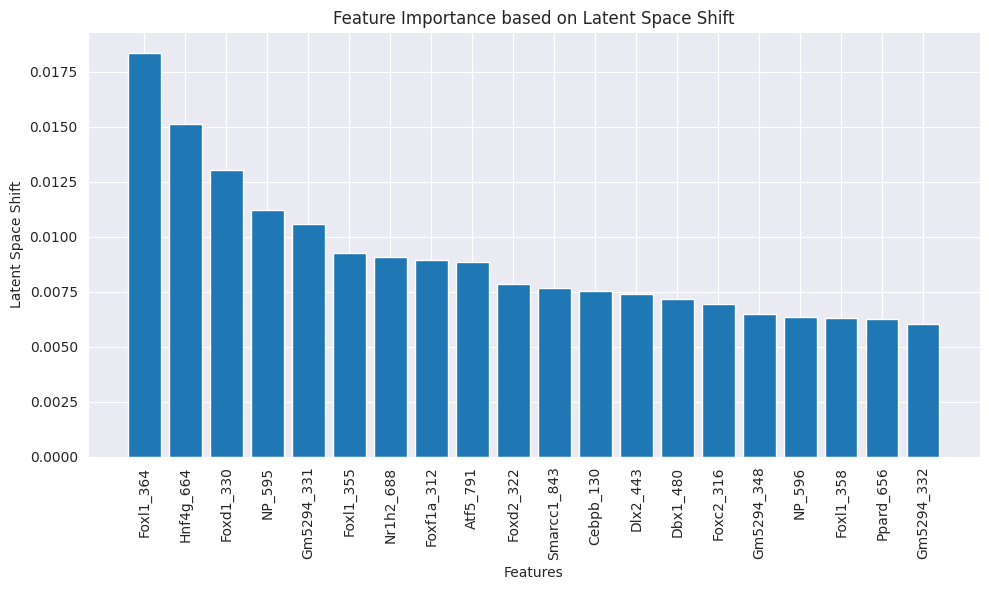

In [18]:

for feature, shift in feature_importance[:20]:
    print(f"{feature}: {shift}")

top_features = feature_importance[:20]
plt.figure(figsize=(10, 6))
plt.bar([f[0] for f in top_features], [f[1] for f in top_features])
plt.xticks(rotation=90)
plt.xlabel('Features')
plt.ylabel('Latent Space Shift')

plt.title('Feature Importance based on Latent Space Shift')
plt.tight_layout()
plt.show()

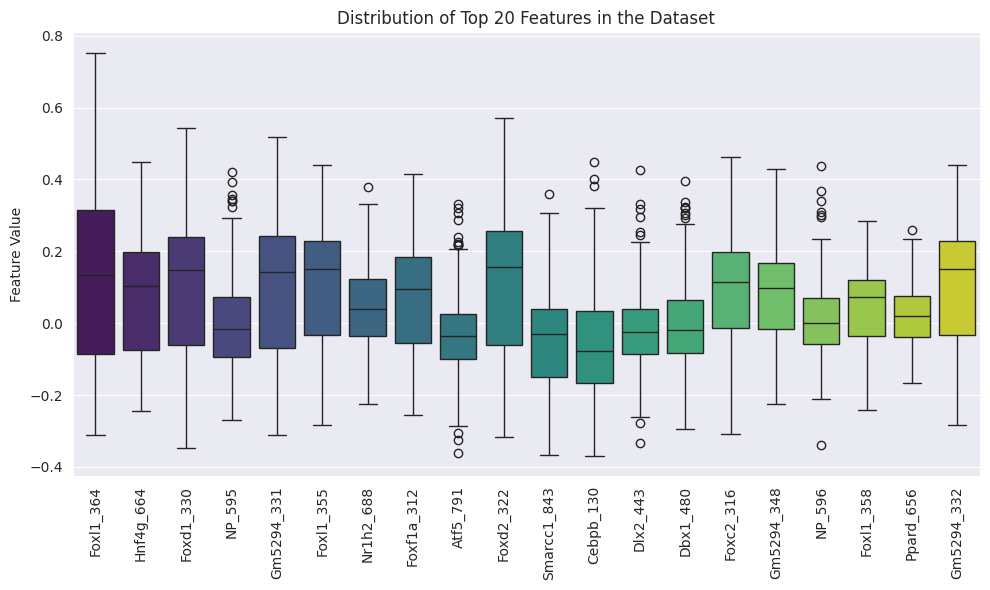

In [19]:
# plot the distribution of the top 20 features in the dataset
top_features_names = [f[0] for f in top_features]
top_features_indices = [atac_names.index(f) for f in top_features_names]
top_features_data = labelled_dataset.tensors[0][:, top_features_indices].numpy()

plt.figure(figsize=(10, 6))
sns.boxplot(data=top_features_data, palette="viridis")
plt.xticks(range(20), top_features_names, rotation=90)
plt.ylabel('Feature Value')
plt.title('Distribution of Top 20 Features in the Dataset')
plt.tight_layout()
plt.show()